In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score,classification_report, confusion_matrix
warnings.filterwarnings('ignore')

In [2]:
import re
import nltk
from nltk.corpus import stopwords
#nltk.download('stopwords')  #uncomment it for first run then comment it back

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aeman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv('flipkart_data.csv')

In [4]:
df.head()

,review,rating
0,It was nice produt. I like it's design a lot. ...,5
1,awesome sound....very pretty to see this nd th...,5
2,awesome sound quality. pros 7-8 hrs of battery...,4
3,I think it is such a good product not only as ...,5
4,awesome bass sound quality very good bettary l...,5


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9976 entries, 0 to 9975
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  9976 non-null   str  
 1   rating  9976 non-null   int64
dtypes: int64(1), str(1)
memory usage: 1.1 MB


In [6]:
df.describe()

,rating
count,9976.000000
mean,4.215417
std,1.167911
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [7]:
df.isnull().sum()

review    0
rating    0
dtype: int64

In [8]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [9]:
# Assuming ratings of 4 and 5 are positive, and 1, 2, 3 are negative.
df['sentiment'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)

In [11]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words]
    
    return ' '.join(cleaned_words)
    
print("Cleaning text data... this might take a moment.")
df['cleaned_review'] = df['review'].apply(clean_text)

Cleaning text data... this might take a moment.


In [12]:
X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

df[['review', 'cleaned_review', 'sentiment']].head()

,review,cleaned_review,sentiment
0,It was nice produt. I like it's design a lot. ...,nice produt like design lot easy carry looked ...,1
1,awesome sound....very pretty to see this nd th...,awesome soundvery pretty see nd sound quality ...,1
2,awesome sound quality. pros 7-8 hrs of battery...,awesome sound quality pros hrs battery life in...,1
3,I think it is such a good product not only as ...,think good product per quality also design qui...,1
4,awesome bass sound quality very good bettary l...,awesome bass sound quality good bettary long l...,1


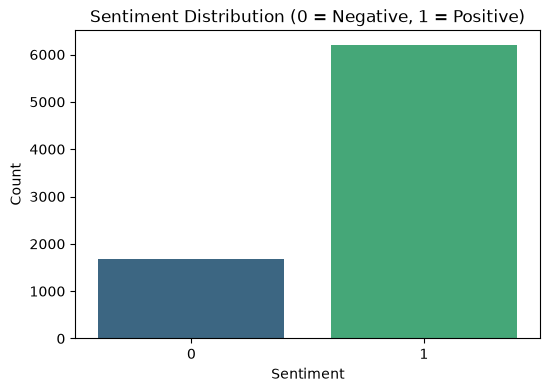

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', palette='viridis') 
plt.title('Sentiment Distribution (0 = Negative, 1 = Positive)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


--- Generating Word Clouds ---


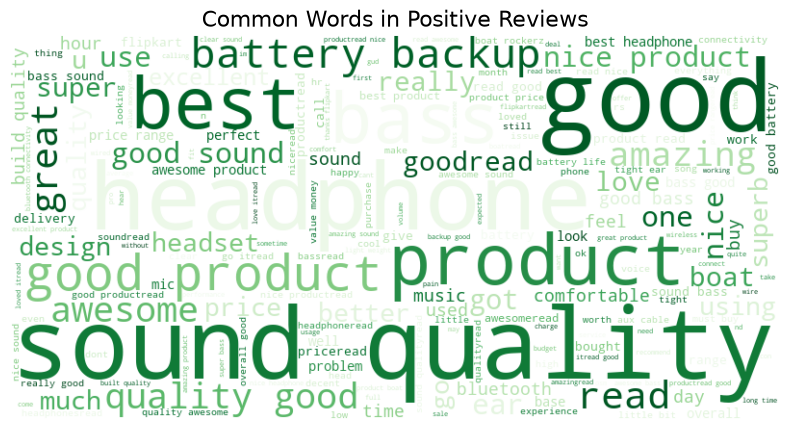

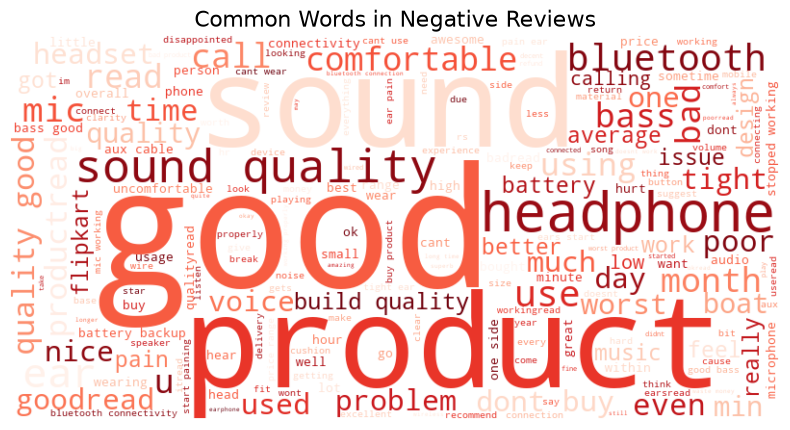

In [18]:
positive_text = ' '.join(df[df['sentiment'] == 1]['cleaned_review'])
negative_text = ' '.join(df[df['sentiment'] == 0]['cleaned_review'])

def plot_wordcloud(text, title, colormap):
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap=colormap).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

print("\n--- Generating Word Clouds ---")
plot_wordcloud(positive_text, 'Common Words in Positive Reviews', 'Greens')
plot_wordcloud(negative_text, 'Common Words in Negative Reviews', 'Reds')

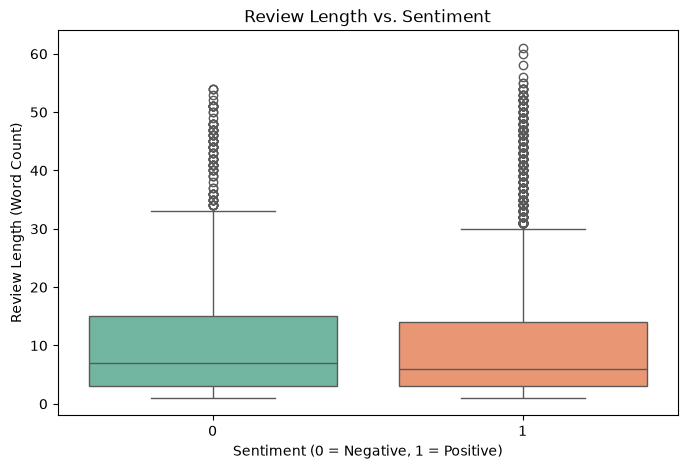

In [16]:
df['review_length'] = df['cleaned_review'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='sentiment', y='review_length', palette='Set2')
plt.title('Review Length vs. Sentiment')
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)')
plt.ylabel('Review Length (Word Count)')
plt.show()

In [17]:
correlation = df['review_length'].corr(df['sentiment'])
print(f"Correlation between Review Length and Sentiment: {correlation:.4f}")

Correlation between Review Length and Sentiment: -0.0197


In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naïve Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine (SVM)": SVC(kernel='linear', random_state=42)
}
results = {
    "Model": [],
    "Accuracy": [],
    "F1-Score": []
}

In [22]:
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results["Model"].append(name)
    results["Accuracy"].append(accuracy)
    results["F1-Score"].append(f1)

In [23]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,F1-Score
0,Support Vector Machine (SVM),0.875476,0.925134
1,Logistic Regression,0.871665,0.923716
2,Random Forest,0.864676,0.919471
3,Naïve Bayes,0.829098,0.902712


In [25]:
best_model = models["Support Vector Machine (SVM)"]
y_pred_best = best_model.predict(X_test_tfidf)

In [28]:
print(classification_report(y_test, y_pred_best, target_names=['Negative (0)', 'Positive (1)']))

              precision    recall  f1-score   support

Negative (0)       0.80      0.52      0.63       321
Positive (1)       0.89      0.97      0.93      1253

    accuracy                           0.88      1574
   macro avg       0.84      0.74      0.78      1574
weighted avg       0.87      0.88      0.86      1574



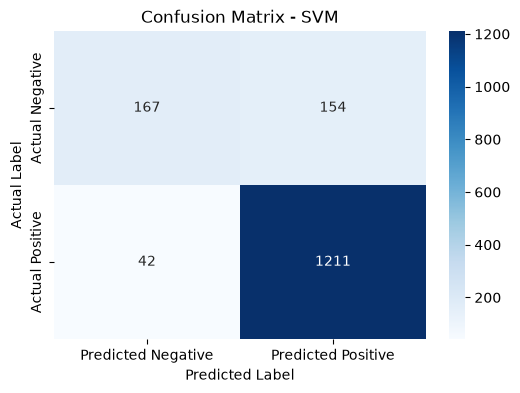

In [29]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [31]:
def predict_sentiment(review_text):
    cleaned_review = clean_text(review_text)
    vectorized_review = tfidf.transform([cleaned_review])
    prediction = best_model.predict(vectorized_review)

    if prediction[0] == 1:
        return "Positive 🟢"
    else:
        return "Negative 🔴"

In [32]:
new_reviews = [
    "Absolutely love this product! The battery life is amazing and the sound is crisp.",
    "Worst purchase ever. It broke after two days and the customer service was terrible.",
    "It's okay, not the best I've used but it gets the job done for the price.",
    "The bass is super powerful, highly recommended for music lovers!"
]

for review in new_reviews:
    sentiment = predict_sentiment(review)
    print(f"Review: '{review}'")
    print(f"Predicted Sentiment: {sentiment}\n")

Review: 'Absolutely love this product! The battery life is amazing and the sound is crisp.'
Predicted Sentiment: Positive 🟢

Review: 'Worst purchase ever. It broke after two days and the customer service was terrible.'
Predicted Sentiment: Negative 🔴

Review: 'It's okay, not the best I've used but it gets the job done for the price.'
Predicted Sentiment: Positive 🟢

Review: 'The bass is super powerful, highly recommended for music lovers!'
Predicted Sentiment: Positive 🟢

